Random array:
[[0.77132064 0.02075195]
 [0.63364823 0.74880388]
 [0.49850701 0.22479665]
 [0.19806286 0.76053071]
 [0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]
 [0.72175532 0.29187607]
 [0.91777412 0.71457578]]


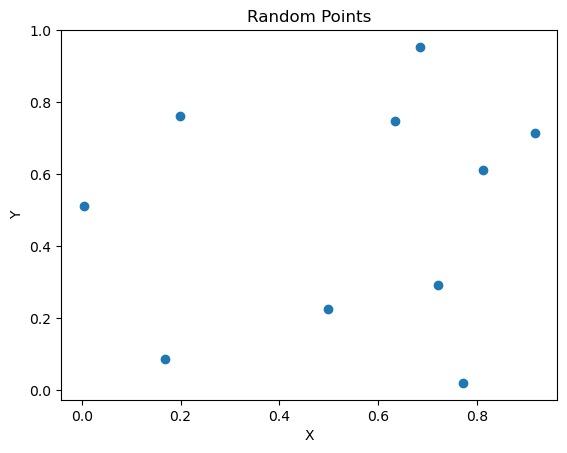

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)
X = np.random.rand(10, 2)
print("Random array:")
print(X)
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Random Points")
plt.show()

In [5]:
import numpy as np
np.random.seed(10)
X = np.random.rand(10, 2)
print("X =")
print(X)
D = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
print("\nSquared distance matrix:")
print(D)
diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
print("\nShape of coordinate differences:", diff.shape)
sq_diff = diff ** 2
print("Shape of squared differences:", sq_diff.shape)
dist = np.sum(sq_diff, axis=2)
print("Shape of summed squared distances:", dist.shape)

X =
[[0.77132064 0.02075195]
 [0.63364823 0.74880388]
 [0.49850701 0.22479665]
 [0.19806286 0.76053071]
 [0.16911084 0.08833981]
 [0.68535982 0.95339335]
 [0.00394827 0.51219226]
 [0.81262096 0.61252607]
 [0.72175532 0.29187607]
 [0.91777412 0.71457578]]

Squared distance matrix:
[[0.         0.54901331 0.11606152 0.8758971  0.36722477 0.87720924
  0.83037395 0.35190232 0.07596501 0.50284013]
 [0.54901331 0.         0.29284673 0.18987213 0.65200778 0.04453094
  0.45250711 0.05060288 0.21654589 0.08189908]
 [0.11606152 0.29284673 0.         0.37727768 0.12712231 0.56576712
  0.32718459 0.24900168 0.05433945 0.41566851]
 [0.8758971  0.18987213 0.37727768 0.         0.45267882 0.27465432
  0.09935246 0.39958703 0.49389096 0.52009615]
 [0.36722477 0.65200778 0.12712231 0.45267882 0.         1.01483062
  0.20692957 0.68887651 0.34684293 0.9526682 ]
 [0.87720924 0.04453094 0.56576712 0.27465432 1.01483062 0.
  0.6589801  0.1323859  0.43892974 0.11105024]
 [0.83037395 0.45250711 0.32718459 0.

In [6]:
import numpy as np
np.random.seed(10)
X = np.random.rand(10, 2)
D = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
print("Diagonal of distance matrix:")
print(np.diag(D))
if np.all(np.diag(D) == 0):
    print("All diagonal values are zero")
else:
    print("Diagonal values are not zero")

Diagonal of distance matrix:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
All diagonal values are zero


In [7]:
import numpy as np
np.random.seed(10)
X = np.random.rand(10, 2)
D = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
order = np.argsort(D, axis=1)
print("Neighbor order:")
print(order)
print("\nFirst column:")
print(order[:, 0])

Neighbor order:
[[0 8 2 7 4 9 1 6 3 5]
 [1 5 7 9 3 8 2 6 0 4]
 [2 8 0 4 7 1 6 3 9 5]
 [3 6 1 5 2 7 4 8 9 0]
 [4 2 6 8 0 3 1 7 9 5]
 [5 1 9 7 3 8 2 6 0 4]
 [6 3 4 2 1 8 5 7 0 9]
 [7 9 1 8 5 2 0 3 6 4]
 [8 2 0 7 1 9 4 5 3 6]
 [9 7 1 5 8 2 0 3 6 4]]

First column:
[0 1 2 3 4 5 6 7 8 9]


In [8]:
K = 2
near = np.argpartition(D, K + 1, axis=1)[:, :K + 1]
print("Nearest points:")
print(near)

Nearest points:
[[0 8 2]
 [5 1 7]
 [8 0 2]
 [6 1 3]
 [2 4 6]
 [5 1 9]
 [4 6 3]
 [9 7 1]
 [8 2 0]
 [1 7 9]]


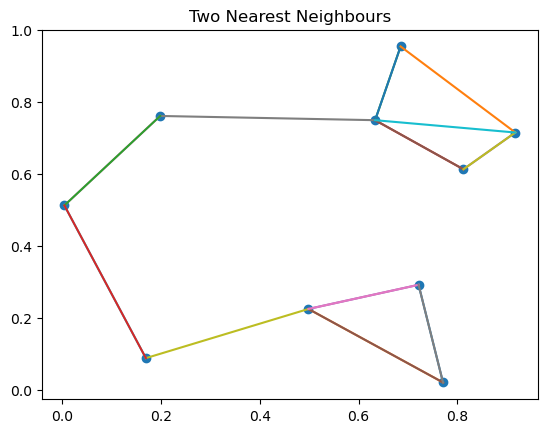

In [9]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(10)
X = np.random.rand(10, 2)
D = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
near = np.argsort(D, axis=1)[:, 1:3]
plt.scatter(X[:, 0], X[:, 1])
for i in range(10):
    for j in near[i]:
        plt.plot([X[i, 0], X[j, 0]],
                 [X[i, 1], X[j, 1]])
plt.title("Two Nearest Neighbours")
plt.show()

In [14]:
import numpy as np
def loop_method(X):
    result = []
    for i in range(len(X)):
        d = np.sum((X - X[i]) ** 2, axis=1)
        result.append(np.argsort(d))
    return np.array(result)
def vector_method(X):
    D = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
    return np.argsort(D, axis=1)
X = np.random.rand(100, 2)
print("N = 100")
print("Loop:")
%timeit loop_method(X)
print("Vectorized:")
%timeit vector_method(X)

N = 100
Loop:
2.4 ms ± 264 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Vectorized:
697 μs ± 92.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [15]:
import numpy as np
def loop_method(X):
    result = []
    for i in range(len(X)):
        d = np.sum((X - X[i]) ** 2, axis=1)
        result.append(np.argsort(d))
    return np.array(result)
def vector_method(X):
    D = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
    return np.argsort(D, axis=1)
X = np.random.rand(100, 2)
print("N = 100")
print("Loop:")
%timeit loop_method(X)
print("Vectorized:")
%timeit vector_method(X)
X = np.random.rand(1000, 2)

N = 100
Loop:
2.23 ms ± 192 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Vectorized:
777 μs ± 75.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
import numpy as np
def loop_method(X):
    result = []
    for i in range(len(X)):
        d = np.sum((X - X[i]) ** 2, axis=1)
        result.append(np.argsort(d))
    return np.array(result)
def vector_method(X):
    D = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
    return np.argsort(D, axis=1)
X = np.random.rand(100, 2)
print("N = 100")
print("Loop:")
%timeit loop_method(X)
print("Vectorized:")
%timeit vector_method(X)
X = np.random.rand(5000, 2)

N = 100
Loop:
2.29 ms ± 227 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Vectorized:
737 μs ± 62.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [18]:
import numpy as np
from sklearn.neighbors import KDTree
np.random.seed(10)
X = np.random.rand(1000, 2)
D = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
numpy_near = np.argsort(D, axis=1)[:, 1:3]
print("NumPy nearest neighbours:")
print(numpy_near[0])
tree = KDTree(X)
dist, tree_near = tree.query(X, k=3)
print("KDTree nearest neighbours:")
print(tree_near[0][1:])
print("NumPy :", numpy_near[0])
print("KDTree:", tree_near[0][1:])
print("NumPy time:")
%timeit np.argsort(np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2), axis=1)[:, 1:3]
print("KDTree time:")
%timeit tree.query(X, k=3)

NumPy nearest neighbours:
[835 820]
KDTree nearest neighbours:
[835 820]
NumPy : [835 820]
KDTree: [835 820]
NumPy time:
97.4 ms ± 2.22 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
KDTree time:
1.48 ms ± 228 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
